In [22]:
import pandas as pd
from glob import glob
import os
import json

In [177]:
dfs = []
for json_path in glob('./logs/finetune_cpb_20250817/*/*/*/*/*/*/*.json'):
    
    path_parts = json_path.split('/')
    model = path_parts[3]
    weights = path_parts[4]
    method = path_parts[-5]
    n_train = int(path_parts[-4].split('_')[-1])
    rep = int(path_parts[-3].split('_')[-1])
    fold = int(path_parts[-2].split('_')[-1])
    
    # if model == 'unet' or weights == 'none':
        # continue
    
    # print(f'Processing {method} rep {rep} fold {fold} with {n_train} training samples')
    metrics_data = json.load(open(json_path, 'r'))
    metrics_data['model'] = model
    metrics_data['weights'] = weights
    metrics_data['method'] = method
    metrics_data['n_train'] = n_train
    metrics_data['rep'] = rep
    metrics_data['fold'] = fold
    dfs.append(pd.DataFrame(metrics_data, index=[0]))

metrics_df = pd.concat(dfs, ignore_index=True)
display(metrics_df)

,accuracy,f1_score,precision,recall,jaccard,kappa,macro_f1_score,macro_precision,macro_recall,macro_jaccard,weighted_f1_score,weighted_precision,weighted_recall,weighted_jaccard,model,weights,method,n_train,rep,fold
0,0.873578,0.871456,0.870511,0.873578,0.785825,0.923405,0.703326,0.745676,0.675206,0.575361,0.871456,0.870511,0.873578,0.785825,unet,imagenet,srs,500,0,4
1,0.873835,0.871463,0.871718,0.873835,0.786770,0.923592,0.685857,0.758748,0.648660,0.556830,0.871463,0.871718,0.873835,0.786770,unet,imagenet,srs,500,0,3
2,0.874743,0.872055,0.871340,0.874743,0.787535,0.924183,0.693577,0.741781,0.669695,0.568907,0.872055,0.871340,0.874743,0.787535,unet,imagenet,srs,500,0,2
3,0.873175,0.871782,0.871629,0.873175,0.786814,0.922921,0.697300,0.736442,0.678762,0.569568,0.871782,0.871629,0.873175,0.786814,unet,imagenet,srs,500,0,1
4,0.868170,0.865136,0.864251,0.868170,0.777979,0.920253,0.664327,0.729914,0.631614,0.537643,0.865136,0.864251,0.868170,0.777979,unet,imagenet,srs,250,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,0.834357,0.826662,0.825655,0.834357,0.729861,0.900507,0.599824,0.652111,0.581072,0.472632,0.826662,0.825655,0.834357,0.729861,deeplabv3plus,none,semss,750,0,1
233,0.813569,0.802276,0.799946,0.813569,0.700195,0.888425,0.521155,0.602856,0.513329,0.404028,0.802276,0.799946,0.813569,0.700195,deeplabv3plus,none,semss,250,0,4
234,0.818911,0.813262,0.812129,0.818911,0.710692,0.890774,0.576527,0.635005,0.546880,0.447404,0.813262,0.812129,0.818911,0.710692,deeplabv3plus,none,semss,250,0,3
235,0.816490,0.808710,0.804981,0.816490,0.708026,0.889656,0.529967,0.556661,0.520309,0.408158,0.808710,0.804981,0.816490,0.708026,deeplabv3plus,none,semss,250,0,2


In [171]:
# metrics_df.loc[(metrics_df.weights == 'none') & (metrics_df.rep <= 1)].groupby(['model', 'weights', 'method', 'n_train']).max().sort_values(by='macro_jaccard', ascending=False)
metrics_df.loc[(metrics_df.rep <= 3)].groupby(['model', 'weights', 'method', 'n_train']).mean().sort_values(by='macro_jaccard', ascending=False)

accuracy  f1_score  precision  \
model         weights  method n_train                                  
unet          imagenet sss    750      0.878978  0.876907   0.876641   
deeplabv3plus imagenet srs    750      0.874454  0.871945   0.870841   
                       semss  750      0.871020  0.868311   0.867605   
unet          imagenet srs    500      0.873833  0.871689   0.871300   
                       semss  500      0.872027  0.868595   0.867902   
deeplabv3plus imagenet sss    750      0.874941  0.871708   0.870660   
unet          imagenet sss    500      0.873018  0.869885   0.869410   
deeplabv3plus imagenet semss  500      0.869094  0.865869   0.865266   
                       srs    500      0.870198  0.866996   0.865676   
                       sss    500      0.868689  0.864954   0.863894   
unet          imagenet semss  250      0.863607  0.860169   0.859669   
                       srs    250      0.865609  0.861599   0.861412   
                       sss    250      0.864522  0.860463   0.860473   
deeplabv3plus imagenet semss  250      0.859695  0.854868   0.854651   
                       sss    250      0.860153  0.855087   0.854301   
                       srs    250      0.858878  0.854052   0.852927   
unet          none     srs    750      0.849620  0.845347   0.843481   
                       semss  750      0.846051  0.843177   0.842925   
                       sss    750      0.846879  0.842012   0.841315   
                       semss  500      0.839783  0.836912   0.836283   
                       srs    500      0.841417  0.836859   0.836126   
                       sss    500      0.841185  0.836528   0.835230   
deeplabv3plus none     sss    750      0.837309  0.831871   0.830449   
                       semss  750      0.830773  0.825364   0.824354   
                       srs    750      0.833126  0.828025   0.826573   
                       sss    500      0.830947  0.824604   0.823807   
unet          none     semss  250      0.825187  0.821928   0.821200   
                       srs    250      0.827346  0.822623   0.821333   
deeplabv3plus none     semss  500      0.826222  0.819614   0.818044   
unet          none     sss    250      0.828671  0.823990   0.822503   
deeplabv3plus none     srs    500      0.827818  0.821924   0.820188   
                       semss  250      0.815379  0.807201   0.804483   
                       srs    250      0.816307  0.806545   0.804440   
                       sss    250      0.814291  0.804659   0.803381   

                                         recall   jaccard     kappa  \
model         weights  method n_train                                 
unet          imagenet sss    750      0.878978  0.793724  0.926618   
deeplabv3plus imagenet srs    750      0.874454  0.786430  0.924088   
                       semss  750      0.871020  0.780831  0.921913   
unet          imagenet srs    500      0.873833  0.786736  0.923525   
                       semss  500      0.872027  0.782236  0.922729   
deeplabv3plus imagenet sss    750      0.874941  0.786298  0.924511   
unet          imagenet sss    500      0.873018  0.784408  0.923217   
deeplabv3plus imagenet semss  500      0.869094  0.778176  0.920859   
                       srs    500      0.870198  0.779800  0.921635   
                       sss    500      0.868689  0.777029  0.920800   
unet          imagenet semss  250      0.863607  0.771177  0.917515   
                       srs    250      0.865609  0.773387  0.918929   
                       sss    250      0.864522  0.771950  0.918244   
deeplabv3plus imagenet semss  250      0.859695  0.763846  0.915459   
                       sss    250      0.860153  0.764829  0.915827   
                       srs    250      0.858878  0.763271  0.914985   
unet          none     srs    750      0.849620  0.752942  0.909157   
                       semss  750      0.846051  0.749969  0.906586   
                       sss

In [172]:
metrics_df

,accuracy,f1_score,precision,recall,jaccard,kappa,macro_f1_score,macro_precision,macro_recall,macro_jaccard,weighted_f1_score,weighted_precision,weighted_recall,weighted_jaccard,model,weights,method,n_train,rep,fold
0,0.873578,0.871456,0.870511,0.873578,0.785825,0.923405,0.703326,0.745676,0.675206,0.575361,0.871456,0.870511,0.873578,0.785825,unet,imagenet,srs,500,0,4
1,0.873835,0.871463,0.871718,0.873835,0.786770,0.923592,0.685857,0.758748,0.648660,0.556830,0.871463,0.871718,0.873835,0.786770,unet,imagenet,srs,500,0,3
2,0.874743,0.872055,0.871340,0.874743,0.787535,0.924183,0.693577,0.741781,0.669695,0.568907,0.872055,0.871340,0.874743,0.787535,unet,imagenet,srs,500,0,2
3,0.873175,0.871782,0.871629,0.873175,0.786814,0.922921,0.697300,0.736442,0.678762,0.569568,0.871782,0.871629,0.873175,0.786814,unet,imagenet,srs,500,0,1
4,0.868170,0.865136,0.864251,0.868170,0.777979,0.920253,0.664327,0.729914,0.631614,0.537643,0.865136,0.864251,0.868170,0.777979,unet,imagenet,srs,250,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,0.834357,0.826662,0.825655,0.834357,0.729861,0.900507,0.599824,0.652111,0.581072,0.472632,0.826662,0.825655,0.834357,0.729861,deeplabv3plus,none,semss,750,0,1
233,0.813569,0.802276,0.799946,0.813569,0.700195,0.888425,0.521155,0.602856,0.513329,0.404028,0.802276,0.799946,0.813569,0.700195,deeplabv3plus,none,semss,250,0,4
234,0.818911,0.813262,0.812129,0.818911,0.710692,0.890774,0.576527,0.635005,0.546880,0.447404,0.813262,0.812129,0.818911,0.710692,deeplabv3plus,none,semss,250,0,3
235,0.816490,0.808710,0.804981,0.816490,0.708026,0.889656,0.529967,0.556661,0.520309,0.408158,0.808710,0.804981,0.816490,0.708026,deeplabv3plus,none,semss,250,0,2


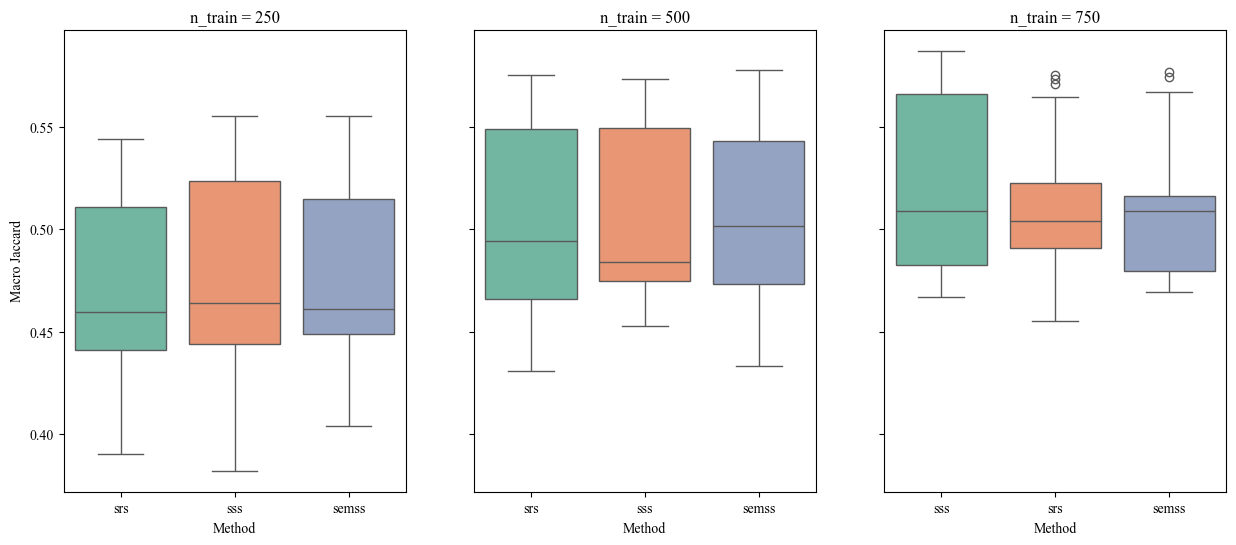

In [179]:
# create boxplot
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'

df = metrics_df.copy()
# df = df[df.weights == 'none']
df = df.loc[df.rep <= 3]
fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
n_train_values = [250, 500, 750]
for i, n_train in enumerate(n_train_values):
    sns.boxplot(data=df[df.n_train == n_train], x='method', y='macro_jaccard', ax=ax[i], palette='Set2', hue='method', legend=False)
    ax[i].set_title(f'n_train = {n_train}')
    ax[i].set_ylabel('Macro Jaccard')
    ax[i].set_xlabel('Method')

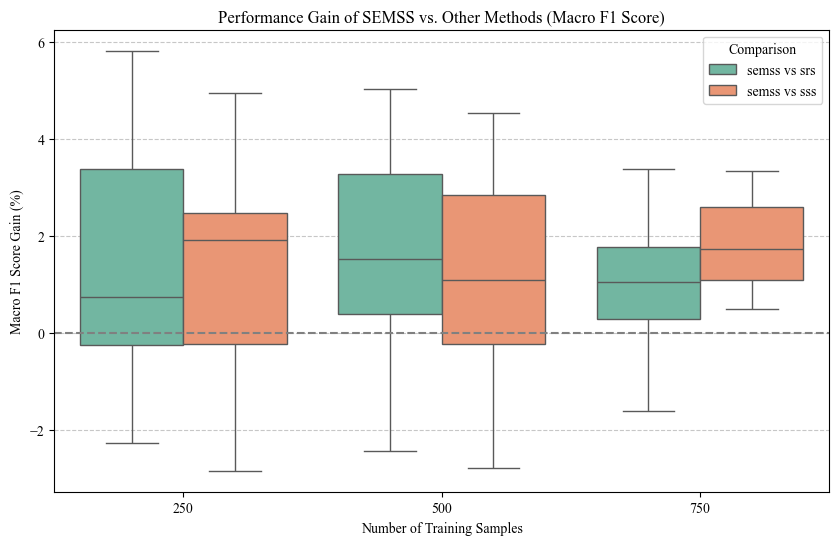

In [166]:

# Create a plot to emphasize the performance gain of SEMSS
df_pivot = df.pivot_table(index=['n_train', 'rep', 'fold'], columns='method', values='macro_f1_score').reset_index()

# Calculate the performance gain of semss over the other methods and convert to percent
df_pivot['semss_gain_vs_srs'] = (df_pivot['semss'] - df_pivot['srs']) * 100
df_pivot['semss_gain_vs_sss'] = (df_pivot['semss'] - df_pivot['sss']) * 100

# Melt the dataframe to make it suitable for plotting with seaborn
df_gain = df_pivot.melt(
    id_vars=['n_train'], 
    value_vars=['semss_gain_vs_srs', 'semss_gain_vs_sss'],
    var_name='comparison',
    value_name='macro_f1_score_gain'
)
df_gain['comparison'] = df_gain['comparison'].str.replace('semss_gain_vs_', 'semss vs ')

# Create the plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_gain, x='n_train', y='macro_f1_score_gain', hue='comparison', palette='Set2')
plt.axhline(0, color='grey', linestyle='--')
plt.title('Performance Gain of SEMSS vs. Other Methods (Macro F1 Score)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Macro F1 Score Gain (%)')
plt.legend(title='Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)


In [182]:
# show differences between methods on a per model/weights basis
df = metrics_df.copy()
df = df.loc[df.rep <= 0]
df
df_pivot = df.pivot_table(index=['model', 'weights', 'n_train'], 
                                   columns='method', 
                                   values='macro_f1_score').reset_index()
# df_pivot = df_pivot.sort_values(by='macro_jaccard', ascending=False)
# display(df_pivot)

df_pivot['semss_gain_vs_srs'] = (df_pivot['semss'] - df_pivot['srs']) * 100
df_pivot['semss_gain_vs_sss'] = (df_pivot['semss'] - df_pivot['sss']) * 100
# df_pivot = df_pivot.melt(
#     id_vars=['model', 'weights', 'n_train'], 
#     value_vars=['semss_gain_vs_srs', 'semss_gain_vs_sss'],
#     var_name='comparison',
#     value_name='macro_jaccard_gain'
# )

# df_pi
df_pivot['min_gain'] = df_pivot[['semss_gain_vs_srs', 'semss_gain_vs_sss']].min(axis=1)
df_pivot['max_gain'] = df_pivot[['semss_gain_vs_srs', 'semss_gain_vs_sss']].max(axis=1)
df_pivot['med_gain'] = df_pivot[['semss_gain_vs_srs', 'semss_gain_vs_sss']].median(axis=1)

df_pivot.groupby(['model', 'weights', 'n_train']).mean().sort_values(by=['weights', 'med_gain'], ascending=False)
    

method                             semss       srs       sss  \
model         weights  n_train                                 
deeplabv3plus none     250      0.540452  0.531427  0.509595   
unet          none     250      0.592975  0.593348  0.578501   
deeplabv3plus none     750      0.606066  0.600051  0.603711   
unet          none     500      0.626680  0.630370  0.616458   
deeplabv3plus none     500      0.581148  0.577097  0.584972   
unet          none     750      0.633659  0.645008  0.632764   
deeplabv3plus imagenet 250      0.647951  0.636042  0.636114   
unet          imagenet 250      0.673008  0.666484  0.662877   
                       500      0.694775  0.695015  0.685741   
deeplabv3plus imagenet 500      0.685362  0.685298  0.677022   
                       750      0.698827  0.701543  0.694418   
unet          imagenet 750           NaN       NaN  0.707524   

method                          semss_gain_vs_srs  semss_gain_vs_sss  \
model         weights  n_train                                         
deeplabv3plus none     250               0.902467           3.085713   
unet          none     250              -0.037380           1.447329   
deeplabv3plus none     750               0.601461           0.235437   
unet          none     500              -0.368916           1.022197   
deeplabv3plus none     500               0.405033          -0.382474   
unet          none     750              -1.134878           0.089522   
deeplabv3plus imagenet 250               1.190863           1.183708   
unet          imagenet 250               0.652376           1.013025   
                       500              -0.024002           0.903364   
deeplabv3plus imagenet 500               0.006412           0.834074   
                       750              -0.271624           0.440896   
unet          imagenet 750                    NaN                NaN   

method                          min_gain  max_gain  med_gain  
model         weights  n_train                                
deeplabv3plus none     250      0.902467  3.085713  1.994090  
unet          none     250     -0.037380  1.447329  0.704975  
deeplabv3plus none     750      0.235437  0.601461  0.418449  
unet          none     500     -0.368916  1.022197  0.326640  
deeplabv3plus none     500     -0.382474  0.405033  0.011280  
unet          none     750     -1.134878  0.089522 -0.522678  
deeplabv3plus imagenet 250      1.183708  1.190863  1.187285  
unet          imagenet 250      0.652376  1.013025  0.832700  
                       500     -0.024002  0.903364  0.439681  
deeplabv3plus imagenet 500      0.006412  0.834074  0.420243  
                       750     -0.271624  0.440896  0.084636  
unet          imagenet 750           NaN       NaN       NaN